<a href="https://colab.research.google.com/github/filippopedrini95/MS_DF_ComputerVision_Project/blob/main/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import keras
import tensorflow as tf

from sklearn.model_selection import train_test_split

from keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

from sklearn.metrics import confusion_matrix

from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import classification_report

#Import Dataset & Images Preprocessing

In [14]:
#import image dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


/workspaces/MS_DF_ComputerVision_Project/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [18]:
#create a reduced version of train dataset
n = 10000
x_train_red, y_train_red = x_train[:n], y_train[:n]

## ResNet50

### image preprocessing for ResNet

test dataset

In [9]:
#image preprocessing to match ResNet input requirements
x_test_resnet = resnet_preprocess(x_test)

reduced dataset

In [10]:
#image preprocessing to match ResNet input requirements
x_train_red_resnet = resnet_preprocess(x_train_red)

In [11]:
#validation set
x_train_red_resnet, x_red_val, y_train_red_resnet, y_red_val = train_test_split(
    x_train_red_resnet,
    y_train_red,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_train_red
)

full dataset

In [13]:
#image preprocessing to match ResNet input requirements
x_train_full_resnet = resnet_preprocess(x_train)

In [14]:
#validation set
x_train_full_resnet, x_full_val, y_train_full_resnet, y_full_val = train_test_split(
    x_train_full_resnet,
    y_train,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_train
)

In [15]:
y_full_val

array([[2],
       [7],
       [1],
       ...,
       [5],
       [9],
       [0]], dtype=uint8)

### No Feature Extractor Optimization

In [21]:
#import ResNet50 for feature extraction
pretrained_model = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(32,32,3),
    pooling="max",
    name="resnet50",
)

pretrained_model.trainable = False # disable ResNet50 parameter optimization


#define the structure of the CNN
cnn_model = Sequential([
    pretrained_model,
    #Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

#optimizer = Adam(learning_rate=1e-4) #Default: 1e-3; Slow: 1e-4

#compile the model
cnn_model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#define early stopping
early_stop = EarlyStopping(
    monitor="val_loss",         # monitors validation loss function
    patience=4,                 # number of steps with no improvements in "val_loss" before stopping the fitting
    restore_best_weights=True   # in case the further "patience" steps made the performance worse, it restores the best weights
)

In [22]:
#model fitting
history = cnn_model.fit(
    x=x_train_full_resnet,
    y=y_train_full_resnet,
    epochs=20,
    batch_size=64, #default: 32
    validation_data=(x_full_val, y_full_val),
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

#try to run for more epochs

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.4677 - loss: 1.6242 - val_accuracy: 0.6243 - val_loss: 1.0861
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6303 - loss: 1.0499 - val_accuracy: 0.6480 - val_loss: 1.0071
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6711 - loss: 0.9339 - val_accuracy: 0.6505 - val_loss: 0.9939
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6930 - loss: 0.8665 - val_accuracy: 0.6606 - val_loss: 0.9822
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7173 - loss: 0.8016 - val_accuracy: 0.6712 - val_loss: 0.9824
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7312 - loss: 0.7440 - val_accuracy: 0.6675 - val_loss: 0.9872
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7436 - loss: 0.7103 - val_accuracy: 0.6625 - val_loss: 1.0260
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7673 - loss: 0.6574 - val_acc

In [ ]:
#save the model after training
#cnn_model.save("resnet_dense128_dropout02_dense32.keras")

#load the model
#cnn_model = keras.models.load_model("resnet_dense128_dropout02_dense32.keras")

In [23]:
#model prediction
y_pred_probs = cnn_model.predict(x_test_resnet)
y_pred = np.argmax(y_pred_probs, axis=1)

#model evaluation parameters
test_loss, test_accuracy = cnn_model.evaluate(x_test_resnet, y_test)
print("\naccuracy:",test_accuracy)
print("loss:",test_loss, end="\n\n")

#classification report
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6632 - loss: 0.9816

accuracy: 0.6657999753952026
loss: 0.9777871966362

              precision    recall  f1-score   support

           0       0.71      0.70      0.71      1000
           1       0.73      0.74      0.74      1000
           2       0.64      0.52      0.57      1000
           3       0.51      0.54      0.52      1000
           4       0.62      0.58      0.60      1000
           5       0.62      0.61      0.61      1000
           6       0.70      0.74      0.72      1000
           7       0.65      0.73      0.69      1000
           8       0.78      0.76      0.77      1000
           9       0.70      0.73      0.72      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.66     10000
weighted avg       0.67      0.67      0.66     10000



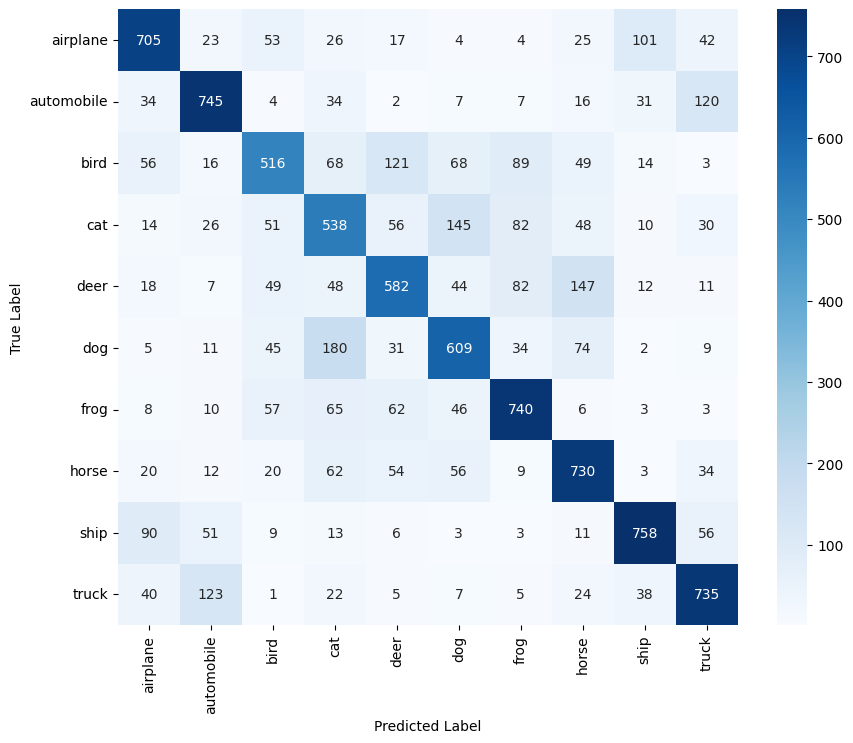

In [24]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('')
plt.show()

##EfficientNetB0

### image preprocessing for EfficientNetB0

test dataset

In [25]:
#image preprocessing to match ResNet input requirements
x_test_effnetb0 = efficientnet_preprocess(x_test)

reduced dataset

In [26]:
#image preprocessing to match ResNet input requirements
x_train_red_effnetb0 = efficientnet_preprocess(x_train_red)

In [27]:
#validation set
x_train_red_effnetb0, x_red_val2, y_train_red_effnetb0, y_red_val2 = train_test_split(
    x_train_red_effnetb0,
    y_train_red,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_train_red
)

In [28]:
x_train_red_effnetb0.shape

(8000, 32, 32, 3)

full dataset

In [29]:
#image preprocessing to match ResNet input requirements
x_train_full_effnetb0 = efficientnet_preprocess(x_train)

In [30]:
#validation set
x_train_full_effnetb0, x_full_val2, y_train_full_effnetb0, y_full_val2 = train_test_split(
    x_train_full_effnetb0,
    y_train,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_train
)

### No Feature Extractor Optim

In [31]:
#import EfficientNetB0 for feature extraction
pretrained_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(32,32,3),
    pooling="max"
)

pretrained_model.trainable = False # disable EffocoemtNetB0 parameter optimization

#for layer in pretrained_model.layers[-1:]:  # activate last 10 layers optimization
#    layer.trainable = True

#define the structure of the CNN
cnn_model = Sequential([
    pretrained_model,
    #Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

#optimizer = Adam(learning_rate=1e-5) #Default: 1e-3; Slow: 1e-4

#compile the model
cnn_model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#define early stopping
early_stop = EarlyStopping(
    monitor="val_loss",         # monitors validation loss function
    patience=4,                 # number of steps with no improvements in "val_loss" before stopping the fitting
    restore_best_weights=True   # in case the further "patience" steps made the performance worse, it restores the best weights
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#model fitting
history = cnn_model.fit(
    x=x_train_full_effnetb0,
    y=y_train_full_effnetb0,
    epochs=50,
    batch_size=64, #default: 32
    validation_data=(x_full_val2, y_full_val2),
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 34ms/step - accuracy: 0.3396 - loss: 1.8100 - val_accuracy: 0.5185 - val_loss: 1.3260
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5033 - loss: 1.3833 - val_accuracy: 0.5431 - val_loss: 1.2738
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5258 - loss: 1.3219 - val_accuracy: 0.5656 - val_loss: 1.2108
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5373 - loss: 1.2878 - val_accuracy: 0.5725 - val_loss: 1.1930
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5486 - loss: 1.2688 - val_accuracy: 0.5801 - val_loss: 1.1609
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5576 - loss: 1.2463 - val_accuracy: 0.5828 - val_loss: 1.1623
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5665 - loss: 1.2143 - val_accuracy: 0.5823 - val_loss: 1.1496
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5690 - loss: 1.2041 - val_accuracy: 

In [ ]:
#Flatten(), Dense(128) + Dropout(0.2) + Dense(32)
#Epoch 13/50
#625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5892 - loss: 1.1503 - val_accuracy: 0.6004 - val_loss: 1.1049

#pooling=max, Dense(128) + Dropout(0.2) + Dense(32)
#Epoch 20/50
#625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6066 - loss: 1.1058 - val_accuracy: 0.6055 - val_loss: 1.0912

In [ ]:
#save the model after training
#cnn_model.save("effnetb0_dense128_dropout02_dense32.keras")